<a href="https://colab.research.google.com/github/kkokay07/Evo2_applications/blob/main/Evo2_Embedding_Extraction_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🧬 Evo2 Embedding Extraction Tool

This notebook extracts embeddings from the **Evo2-40B** foundation model using the NVIDIA API.

## Features:
- Extract embeddings from **two layers simultaneously**:
  - **Last layer** (`blocks.26.mlp.l3`): 8192 dimensions
  - **15th block** (`blocks.15`): 8192 dimensions
- Upload sequences in **FASTA format**
- Download results as CSV or NPZ files

## Setup Instructions:
1. Get your NVIDIA API key from: https://build.nvidia.com/arc/evo2-40b
2. Run each cell sequentially
3. Upload your FASTA file when prompted
4. Download the embedding results

# Creator: Dr. KANAKA K. K.
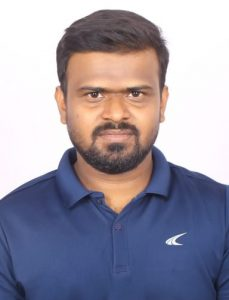

PhD, ARS  
Scientist

School of Bioinformatics and Computational Biology

ICAR-Indian Institute of Agricultural Biotechnology, Ranchi, Jharkhand.

Spy on me at :)  
[Google Scholar](https://scholar.google.com/citations?hl=en&user=0dQ7Sf8AAAAJ&view_op=list_works);    [ResearchGate](https://www.researchgate.net/profile/Kanaka-K-K/research);    [Website](https://iiab.icar.gov.in/staff/dr-kanaka-k-k/)

## Step 1: Install Required Packages

In [ ]:
# Install required packages
!pip install -q biopython requests pandas numpy tqdm
print("✅ Packages installed successfully!")

## Step 2: Import Libraries

In [ ]:
import requests
import base64
import io
import json
import time
import numpy as np
import pandas as pd
from Bio import SeqIO
from pathlib import Path
from tqdm import tqdm
from google.colab import files
from getpass import getpass
import warnings
warnings.filterwarnings('ignore')

print("✅ Libraries imported successfully!")

## Step 3: Configure API Key

Enter your NVIDIA API key. You can get one from: https://build.nvidia.com/arc/evo2-40b

In [ ]:
# Prompt for API key (hidden input for security)
print("🔑 Please enter your NVIDIA API key:")
print("(Get your key from: https://build.nvidia.com/explore/discover)")
API_KEY = getpass("API Key: ")

# API Configuration
API_URL = "https://health.api.nvidia.com/v1/biology/arc/evo2-40b/forward"

# Layer configurations
LAYERS = {
    "last_layer": "blocks.26.mlp.l3",      # Last layer
    "block_15": "blocks.15"                 # 15th block
}

# Verify API key is provided
if not API_KEY or API_KEY.strip() == "":
    raise ValueError("❌ API key is required! Please provide a valid NVIDIA API key.")

print("✅ API configuration set!")
print(f"   API URL: {API_URL}")
print(f"   Layers to extract: {list(LAYERS.keys())}")
print(f"   - Last layer (blocks.26.mlp.l3)")
print(f"   - 15th block (blocks.15)")
print(f"   Note: Evo2-40B uses 8192 dimensions for all layers")

## Step 4: Upload FASTA File

Upload your DNA sequences in FASTA format. Each sequence should be at least 200bp for optimal results.

In [ ]:
print("📤 Please upload your FASTA file:")
print("(Click 'Choose Files' to select your .fa or .fasta file)")
uploaded = files.upload()

# Get the uploaded filename
if len(uploaded) == 0:
    raise ValueError("❌ No file uploaded! Please upload a FASTA file.")

fasta_filename = list(uploaded.keys())[0]

# Save the uploaded file
with open(fasta_filename, 'wb') as f:
    f.write(uploaded[fasta_filename])

print(f"\n✅ Uploaded: {fasta_filename}")
print(f"   File size: {len(uploaded[fasta_filename]):,} bytes")

## Step 5: Parse and Validate FASTA File

In [ ]:
# Parse FASTA file
print("🔍 Parsing FASTA file...")
records = list(SeqIO.parse(fasta_filename, "fasta"))
n_seqs = len(records)

if n_seqs == 0:
    raise ValueError("❌ No sequences found in the FASTA file!")

print(f"✅ Loaded {n_seqs:,} sequences")

# Display first few sequences
print("\n📋 Your sequence/s (first 3 only):")
for i, record in enumerate(records[:3]):
    seq_len = len(record.seq)
    seq_preview = str(record.seq)[:50] + "..." if seq_len > 50 else str(record.seq)
    print(f"   {i+1}. {record.id} ({seq_len:,} bp): {seq_preview}")

if n_seqs > 3:
    print(f"   ... and {n_seqs - 3} more sequences")

# Sequence length statistics
seq_lengths = [len(r.seq) for r in records]
print(f"\n📊 Sequence length statistics:")
print(f"   Min: {min(seq_lengths):,} bp")
print(f"   Max: {max(seq_lengths):,} bp")
print(f"   Mean: {np.mean(seq_lengths):.1f} bp")
print(f"   Median: {np.median(seq_lengths):.1f} bp")

## Step 6: Define Embedding Extraction Functions

In [ ]:
def extract_embedding(sequence, api_key, seq_id="", extract_position="center"):
    """
    Extract embeddings from Evo2-40B for a single sequence.

    Args:
        sequence: DNA sequence string (A, C, T, G, N)
        api_key: NVIDIA API key
        seq_id: Sequence identifier for logging
        extract_position: Position to extract embedding ('center' or integer index)

    Returns:
        dict with embeddings from both layers or None if failed
    """
    # Clean sequence
    seq = str(sequence).upper()

    # Determine extraction position
    if extract_position == "center":
        pos = len(seq) // 2
    else:
        pos = int(extract_position)

    try:
        # Make API request
        response = requests.post(
            API_URL,
            headers={"Authorization": f"Bearer {api_key}"},
            json={
                "sequence": seq,
                "output_layers": list(LAYERS.values())  # Request both layers
            },
            timeout=120
        )

        if response.status_code == 200:
            data = response.json()

            if 'data' in data:
                # Decode base64 response
                decoded = base64.b64decode(data['data'].encode("ascii"))
                npz = np.load(io.BytesIO(decoded))

                # Extract embeddings from both layers
                result = {}

                # Last layer (blocks.26.mlp.l3)
                layer_last = LAYERS['last_layer']
                key_last = f'{layer_last}.output'
                if key_last in npz.files:
                    emb_last = npz[key_last]
                    # Extract at specified position
                    if len(emb_last.shape) == 3:  # (batch, seq_len, dim)
                        result['last_layer'] = emb_last[0, pos, :].astype(np.float32)
                    elif len(emb_last.shape) == 2:  # (seq_len, dim)
                        result['last_layer'] = emb_last[pos, :].astype(np.float32)
                    result['last_layer_dim'] = result['last_layer'].shape[0]

                # 15th block (blocks.15)
                layer_15 = LAYERS['block_15']
                key_15 = f'{layer_15}.output'
                if key_15 in npz.files:
                    emb_15 = npz[key_15]
                    # Extract at specified position
                    if len(emb_15.shape) == 3:  # (batch, seq_len, dim)
                        result['block_15'] = emb_15[0, pos, :].astype(np.float32)
                    elif len(emb_15.shape) == 2:  # (seq_len, dim)
                        result['block_15'] = emb_15[pos, :].astype(np.float32)
                    result['block_15_dim'] = result['block_15'].shape[0]

                return result
            else:
                return {"error": "No data in response"}
        else:
            return {"error": f"HTTP {response.status_code}: {response.text[:200]}"}

    except requests.exceptions.Timeout:
        return {"error": "Request timeout"}
    except Exception as e:
        return {"error": str(e)}


def extract_embeddings_batch(records, api_key, extract_position="center", delay=0.5):
    """
    Extract embeddings for all sequences with progress tracking.

    Args:
        records: List of SeqIO records
        api_key: NVIDIA API key
        extract_position: Position to extract embedding
        delay: Delay between requests (seconds)

    Returns:
        results_dict with embeddings and metadata
    """
    n_seqs = len(records)

    # Initialize storage
    results = {
        'seq_ids': [],
        'sequences': [],
        'last_layer': [],
        'block_15': [],
        'failed': [],
        'errors': []
    }

    print(f"\n🚀 Starting extraction for {n_seqs:,} sequences...")
    print(f"   Extracting from: Center position")
    print(f"   Layers: Last layer + Block 15")
    print(f"   Delay between requests: {delay}s\n")

    start_time = time.time()

    for i in tqdm(range(n_seqs), desc="Processing sequences"):
        record = records[i]
        seq_id = record.id
        seq = str(record.seq).upper()

        # Extract embeddings
        result = extract_embedding(seq, api_key, seq_id, extract_position)

        if result and 'error' not in result:
            # Success - store embeddings
            results['seq_ids'].append(seq_id)
            results['sequences'].append(seq)
            results['last_layer'].append(result.get('last_layer', np.array([])))
            results['block_15'].append(result.get('block_15', np.array([])))
            results['last_layer_dim'] = result.get('last_layer_dim', 0)
            results['block_15_dim'] = result.get('block_15_dim', 0)
        else:
            # Failed - store empty arrays (will fill with NaN later)
            results['seq_ids'].append(seq_id)
            results['sequences'].append(seq)
            results['last_layer'].append(np.array([]))
            results['block_15'].append(np.array([]))
            results['failed'].append(i)
            error_msg = result.get('error', 'Unknown error') if result else 'No result'
            results['errors'].append(f"{seq_id}: {error_msg}")

        # Rate limiting
        if i < n_seqs - 1:
            time.sleep(delay)

    elapsed = time.time() - start_time
    success_count = n_seqs - len(results['failed'])

    # Determine dimensions from first successful extraction
    last_layer_dim = 8192  # Default for Evo2-40B
    block_15_dim = 8192    # Default for Evo2-40B
    for i in range(n_seqs):
        if i not in results['failed'] and len(results['last_layer'][i]) > 0:
            last_layer_dim = len(results['last_layer'][i])
            block_15_dim = len(results['block_15'][i])
            break

    # Fill empty arrays with NaN placeholders for failed sequences
    for i in range(n_seqs):
        if len(results['last_layer'][i]) == 0:
            results['last_layer'][i] = np.full(last_layer_dim, np.nan)
        if len(results['block_15'][i]) == 0:
            results['block_15'][i] = np.full(block_15_dim, np.nan)

    # Store dimensions in results
    results['last_layer_dim'] = last_layer_dim
    results['block_15_dim'] = block_15_dim

    print(f"\n✅ Extraction complete!")
    print(f"   Total: {n_seqs:,} sequences")
    print(f"   Successful: {success_count:,}")
    print(f"   Failed: {len(results['failed'])}")
    print(f"   Last Layer Dim: {last_layer_dim}")
    print(f"   Block 15 Dim: {block_15_dim}")
    print(f"   Time: {elapsed:.1f}s ({elapsed/n_seqs:.2f}s per sequence)")

    return results

print("✅ Extraction functions defined!")

## Step 7: Extract Embeddings

⚠️ **Note:** This may take some time depending on the number of sequences. The API has rate limits, so we add a small delay between requests.

In [ ]:
# Set delay between API requests (seconds)
# Adjust based on your API rate limits
REQUEST_DELAY = 0.5  # 500ms between requests

# Run extraction
extraction_results = extract_embeddings_batch(
    records=records,
    api_key=API_KEY,
    extract_position="center",
    delay=REQUEST_DELAY
)

## Step 8: Convert to DataFrames and Display Results

In [ ]:
# Convert embeddings to numpy arrays
last_layer_embeddings = np.array(extraction_results['last_layer'])
block_15_embeddings = np.array(extraction_results['block_15'])

# Get actual dimensions from extraction
last_layer_dim = extraction_results.get('last_layer_dim', last_layer_embeddings.shape[1])
block_15_dim = extraction_results.get('block_15_dim', block_15_embeddings.shape[1])

print("📊 Embedding Dimensions:")
print(f"   Last Layer (blocks.26.mlp.l3): {last_layer_embeddings.shape}")
print(f"   Block 15 (blocks.15): {block_15_embeddings.shape}")

# Create metadata DataFrame
metadata_df = pd.DataFrame({
    'seq_id': extraction_results['seq_ids'],
    'sequence': extraction_results['sequences'],
    'seq_length': [len(s) for s in extraction_results['sequences']],
    'extraction_successful': [i not in extraction_results['failed'] for i in range(len(extraction_results['seq_ids']))]
})

print("\n📋 Metadata preview:")
print(metadata_df.head(10))

# Create embedding DataFrames
# Last layer
last_layer_cols = [f'last_dim_{i}' for i in range(last_layer_dim)]
last_layer_df = pd.DataFrame(last_layer_embeddings, columns=last_layer_cols)
last_layer_df.insert(0, 'seq_id', extraction_results['seq_ids'])

# Block 15
block_15_cols = [f'block15_dim_{i}' for i in range(block_15_dim)]
block_15_df = pd.DataFrame(block_15_embeddings, columns=block_15_cols)
block_15_df.insert(0, 'seq_id', extraction_results['seq_ids'])

print("\n📋 Last Layer Embedding preview:")
print(last_layer_df.iloc[:5, :min(5, last_layer_dim+1)])

print("\n📋 Block 15 Embedding preview:")
print(block_15_df.iloc[:5, :min(5, block_15_dim+1)])

## Step 9: Save results

Results will be saved in multiple formats for your convenience.

In [ ]:
# Create output filenames based on input
base_name = Path(fasta_filename).stem

# Get dimensions for filenames
last_dim = extraction_results.get('last_layer_dim', 8192)
block15_dim = extraction_results.get('block_15_dim', 8192)

# Save as NPZ (compact binary format, recommended)
npz_filename = f"{base_name}_evo2_embeddings.npz"
np.savez_compressed(
    npz_filename,
    metadata=metadata_df.to_dict('records'),
    last_layer=last_layer_embeddings,
    block_15=block_15_embeddings,
    seq_ids=extraction_results['seq_ids'],
    failed_indices=np.array(extraction_results['failed']),
    last_layer_dim=last_dim,
    block_15_dim=block15_dim
)
print(f"✅ Saved NPZ: {npz_filename}")

# Save metadata as CSV
metadata_filename = f"{base_name}_metadata.csv"
metadata_df.to_csv(metadata_filename, index=False)
print(f"✅ Saved Metadata CSV: {metadata_filename}")

# Save last layer embeddings as CSV (may be large)
last_layer_filename = f"{base_name}_last_layer_{last_dim}dim.csv"
last_layer_df.to_csv(last_layer_filename, index=False)
print(f"✅ Saved Last Layer CSV: {last_layer_filename}")

# Save block 15 embeddings as CSV (may be large)
block_15_filename = f"{base_name}_block15_{block15_dim}dim.csv"
block_15_df.to_csv(block_15_filename, index=False)
print(f"✅ Saved Block 15 CSV: {block_15_filename}")

# Save failed sequences info
if extraction_results['failed']:
    failed_df = pd.DataFrame({
        'index': extraction_results['failed'],
        'seq_id': [extraction_results['seq_ids'][i] for i in extraction_results['failed']],
        'error': extraction_results['errors']
    })
    failed_filename = f"{base_name}_failed.csv"
    failed_df.to_csv(failed_filename, index=False)
    print(f"✅ Saved Failed Sequences: {failed_filename}")

# Display file sizes
print("\n📁 File sizes:")
for f in [npz_filename, metadata_filename, last_layer_filename, block_15_filename]:
    if Path(f).exists():
        size_mb = Path(f).stat().st_size / (1024 * 1024)
        size_kb = Path(f).stat().st_size / 1024
        if size_mb >= 1:
            print(f"   {f}: {size_mb:.2f} MB")
        else:
            print(f"   {f}: {size_kb:.2f} KB")

## Step 10: Download Files

Click the download buttons below to save the files to your computer.

In [ ]:
print("⬇️ Downloading files...\n")

# Download NPZ (all embeddings in one file)
print("1. Downloading NPZ file (all embeddings)...")
files.download(npz_filename)

print("\n2. Downloading Metadata CSV...")
files.download(metadata_filename)

print(f"\n3. Downloading Last Layer CSV ({last_dim} dimensions)...")
files.download(last_layer_filename)

print(f"\n4. Downloading Block 15 CSV ({block15_dim} dimensions)...")
files.download(block_15_filename)

if extraction_results['failed']:
    print("\n5. Downloading Failed Sequences CSV...")
    files.download(failed_filename)

print("\n✅ All downloads initiated! Check your browser's download folder.")

---

## 🔧 Troubleshooting

### Common Issues:

1. **API Key Invalid**
   - Make sure you have a valid NVIDIA API key from https://build.nvidia.com/explore/discover
   - Check that the key is entered correctly (no extra spaces)

2. **Rate Limiting**
   - If you get rate limit errors, increase the `REQUEST_DELAY` parameter
   - Default is 0.5 seconds between requests

3. **Timeout Errors**
   - Long sequences may cause timeouts
   - Try splitting long sequences into smaller chunks (< 10kb)

4. **Memory Issues**
   - For very large FASTA files, the embeddings may use significant memory
   - Consider processing in batches if you have >10,000 sequences

5. **Failed Extractions**
   - Check the `_failed.csv` file for specific error messages
   - Common causes: invalid characters in sequence, network issues

---

## 📚 References

- **NVIDIA API**: https://build.nvidia.com/explore/discover
- **Evo2 GitHub**: https://github.com/ArcInstitute/evo2

---

**Created for**: Transfer Learning Research - Cattle to Buffalo Genomic Prediction

**Model**: Evo2-40B (40 billion parameters)

**Layers**:
- Last Layer (`blocks.26.mlp.l3`): 8192 dimensions
- Block 15 (`blocks.15`): 8192 dimensions
(Evo2-40B uses 8192 dimensions for all layers)